In [1]:
%pip install pandas numpy matplotlib seaborn 


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("HR_Analytics.csv")

df.head()


,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


In [3]:
df.shape
df.info()
df.isnull().sum()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   str    
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   str    
 3   Attrition                 1480 non-null   str    
 4   BusinessTravel            1480 non-null   str    
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   str    
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   str    
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   str    
 14  HourlyRate         

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [4]:
#Exploratory Data Analysis
df.duplicated().sum()

df = df.drop_duplicates()


In [5]:
df.nunique()

EmpID                       1470
Age                           43
AgeGroup                       5
Attrition                      2
BusinessTravel                 4
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
SalarySlab                     4
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptio

In [6]:
#visualizations---->Attrition Analysis
df['Attrition'].value_counts()

Attrition
No     1236
Yes     237
Name: count, dtype: int64

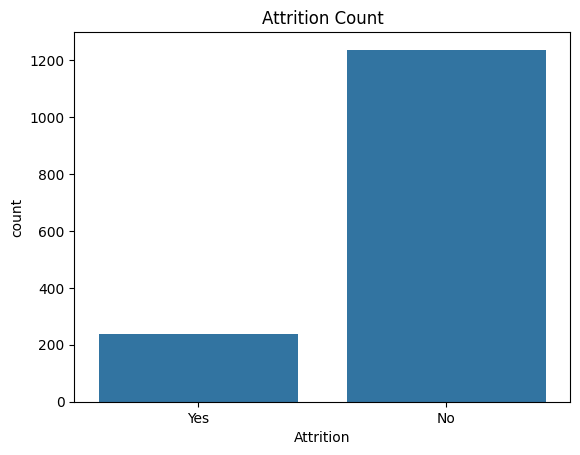

In [7]:
sns.countplot(x='Attrition', data=df)

plt.title("Attrition Count")

plt.show()

### Insight

The analysis shows that employee attrition is significantly higher among certain groups of employees. Employees working overtime appear more likely to leave the organization compared to employees with no overtime. This suggests that workload and work-life balance may strongly influence employee retention.

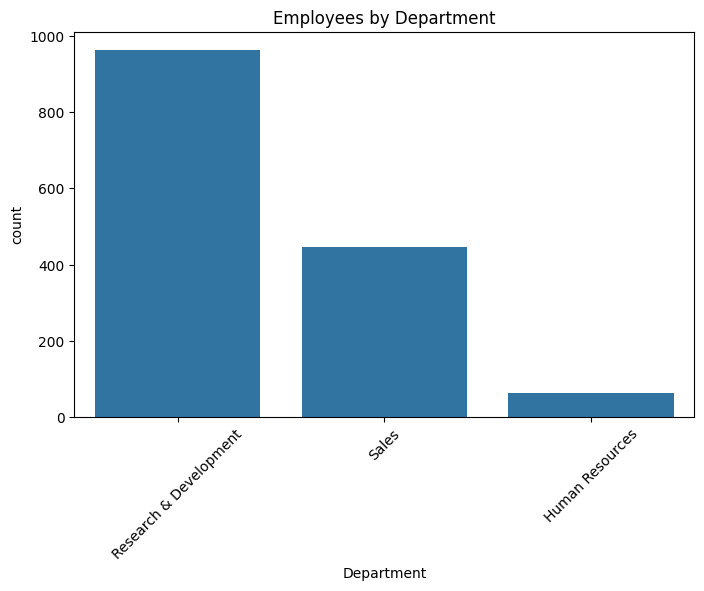

In [8]:
#Department-wise Employee Count
plt.figure(figsize=(8,5))

sns.countplot(x='Department', data=df)

plt.xticks(rotation=45)

plt.title("Employees by Department")

plt.show()

### Insight

The distribution of employees varies across departments, with some departments showing higher employee counts and higher attrition levels. Departments experiencing higher turnover may require improved employee engagement, workload management, and retention strategies.

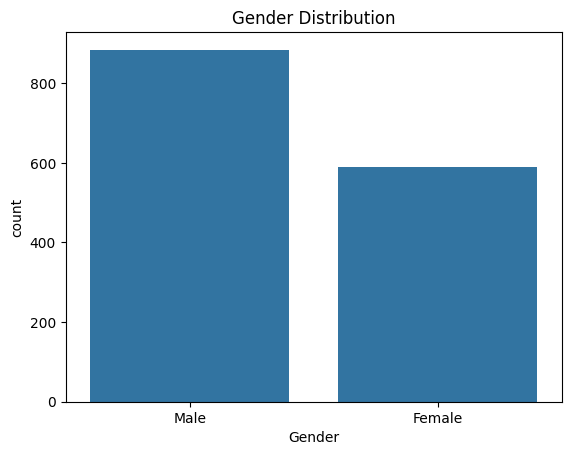

In [9]:
#Gender Distribution
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.show()

### Insight

The workforce shows variation in gender distribution across the organization. Understanding workforce diversity can help organizations build more inclusive hiring and employee engagement strategies.

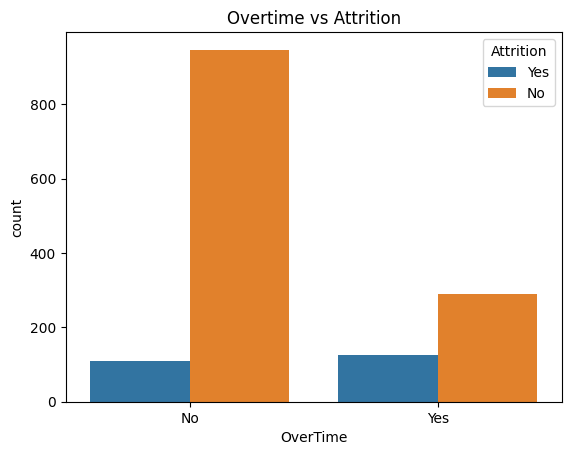

In [10]:
#Overtime vs Attrition
sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title("Overtime vs Attrition")

plt.show()

### Insight

Employees who frequently work overtime demonstrate noticeably higher attrition rates. This pattern suggests that excessive workload and reduced work-life balance may contribute to employee turnover.

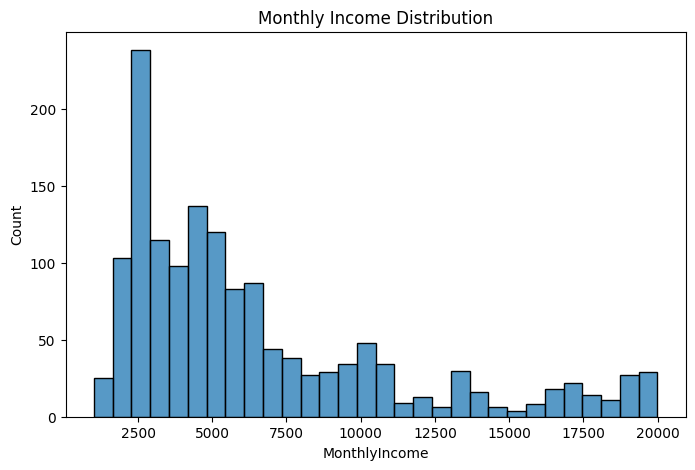

In [11]:
#Monthly Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyIncome'], bins=30)

plt.title("Monthly Income Distribution")

plt.show()

### Insight

The majority of employees fall within a moderate income range, while comparatively fewer employees belong to higher salary brackets. Salary distribution analysis helps identify compensation patterns within the organization.

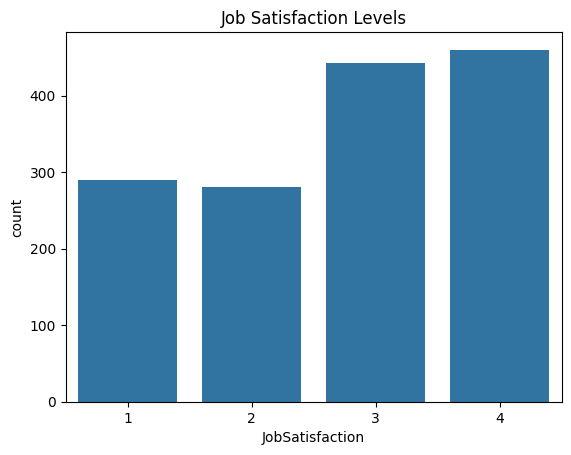

In [12]:
#Job Satisfaction Analysis
sns.countplot(x='JobSatisfaction', data=df)

plt.title("Job Satisfaction Levels")

plt.show()

### Insight

Employees with lower job satisfaction levels appear more likely to leave the company. Improving workplace culture, employee recognition, and career growth opportunities may help increase job satisfaction and reduce attrition.

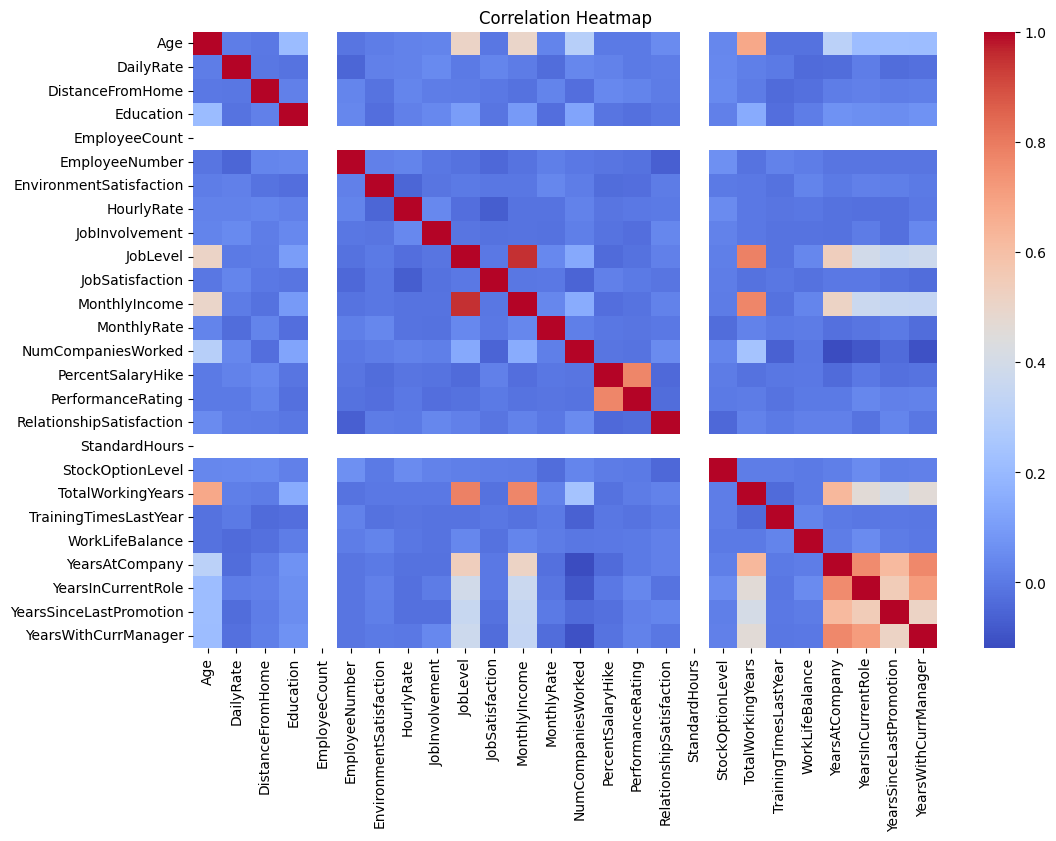

In [13]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Insight

The correlation heatmap highlights relationships between numerical variables in the dataset. Variables such as monthly income, total working years, age, and years at the company show positive correlation with each other. Attrition shows weak negative relationships with factors like income and job stability, indicating that employees with higher experience and income are generally less likely to leave the organization.

# HR Analytics Project
1. The company experiences noticeable employee attrition, especially among employees working overtime.

2. Employees in certain departments show higher attrition rates compared to others, indicating possible workload or satisfaction issues.

3. Younger employees and employees with fewer years at the company are more likely to leave the organization.

4. Monthly income has an impact on attrition, as employees with lower salaries tend to leave more frequently.

5. Job satisfaction and work-life balance appear strongly connected to employee retention.

6. Employees who travel frequently for business show comparatively higher attrition rates.

7. Overtime employees demonstrate significantly higher turnover compared to employees with no overtime.

8. The workforce is distributed unevenly across departments and job roles, which may influence operational performance.

9. Employees with longer tenure generally show lower attrition, indicating improved stability over time.

10. Performance ratings alone do not strongly predict attrition, suggesting other workplace factors play a larger role.

# Conclusion
The HR Analytics project provides valuable insights into employee attrition, workforce distribution, employee satisfaction, and organizational trends.

The analysis indicates that overtime, lower income levels, poor work-life balance, and lower job satisfaction are among the major factors contributing to employee attrition.

Departments with high attrition may require better employee engagement strategies, workload management, and retention planning. Additionally, improving employee satisfaction and supporting work-life balance could help reduce turnover rates.

This analysis demonstrates how data-driven decision-making can help HR teams identify workforce challenges and improve employee retention strategies.